In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
# Ruta al dataset
DATA_PATH = Path("../data/processed/project_risk_clean.csv")


# Leer el dataset
df = pd.read_csv(DATA_PATH)
X = df.drop("Risk_Level", axis=1)
y = df["Risk_Level"]


# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [3]:
# Preprocesamiento
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
], remainder="drop")

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# **XGBoost**

Accuracy: 0.6
Recall: 0.6
Precision: 0.613335367182288
F1-score: 0.6026129720065705

Classification Report:
              precision    recall  f1-score   support

    Critical       0.79      0.61      0.69       228
        High       0.46      0.46      0.46       311
         Low       0.73      0.65      0.69       242
      Medium       0.56      0.66      0.61       419

    accuracy                           0.60      1200
   macro avg       0.64      0.60      0.61      1200
weighted avg       0.61      0.60      0.60      1200



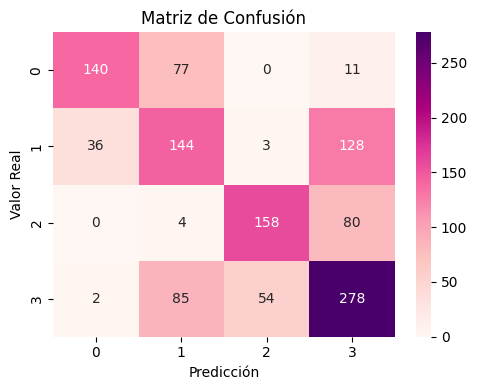

In [4]:
model = xgb.XGBClassifier(eval_metric='logloss')
model.fit(X_train_prep, y_train_encoded)

y_pred = model.predict(X_test_prep)
y_pred_labels = encoder.inverse_transform(y_pred)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Recall:", recall_score(y_test, y_pred_labels, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_labels, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_labels, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))


# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='RdPu')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

In [5]:
# Busca de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'eval_metric': ['logloss', 'mlogloss']
}

grid = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss'),
    param_distributions=param_grid,
    n_iter=50,
    scoring='accuracy',
    cv=3,
    verbose=3,
    random_state=42
)
grid.fit(X_train_prep, y_train_encoded)

print("Mejores parámetros:", grid.best_params_) #{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1} recall 0.6416
# {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1, 'eval_metric': 'mlogloss'} recall 0.6366
#  {'subsample': 1.0, 'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.1, 'eval_metric': 'logloss'} recall 0.655

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV 1/3] END eval_metric=logloss, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.6;, score=0.517 total time=   1.7s
[CV 2/3] END eval_metric=logloss, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.6;, score=0.513 total time=   1.2s
[CV 3/3] END eval_metric=logloss, learning_rate=0.01, max_depth=7, n_estimators=100, subsample=0.6;, score=0.518 total time=   1.4s
[CV 1/3] END eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=500, subsample=1.0;, score=0.601 total time=   2.1s
[CV 2/3] END eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=500, subsample=1.0;, score=0.584 total time=   2.2s
[CV 3/3] END eval_metric=logloss, learning_rate=0.1, max_depth=5, n_estimators=500, subsample=1.0;, score=0.618 total time=   2.8s
[CV 1/3] END eval_metric=logloss, learning_rate=0.05, max_depth=7, n_estimators=200, subsample=0.8;, score=0.582 total time=   2.2s
[CV 2/3] END eval

Accuracy: 0.6566666666666666
Recall: 0.6566666666666666
Precision: 0.6632646009032572
F1-score: 0.6585810370941564

Classification Report:
              precision    recall  f1-score   support

    Critical       0.80      0.68      0.74       228
        High       0.52      0.53      0.53       311
         Low       0.77      0.74      0.76       242
      Medium       0.63      0.68      0.66       419

    accuracy                           0.66      1200
   macro avg       0.68      0.66      0.67      1200
weighted avg       0.66      0.66      0.66      1200



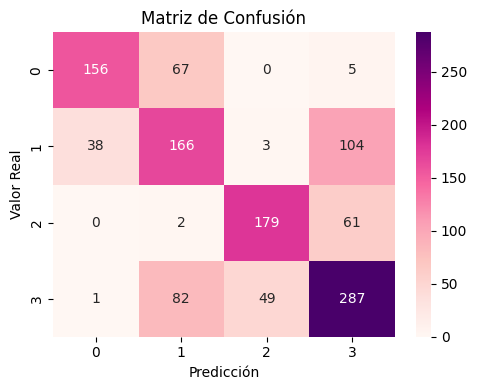

In [6]:
model_xgb_best = xgb.XGBClassifier(eval_metric='mlogloss', subsample= 1, n_estimators= 800, max_depth= 3, learning_rate= 0.3)
model_xgb_best.fit(X_train_prep, y_train_encoded)

y_pred = model_xgb_best.predict(X_test_prep)
y_pred_labels = encoder.inverse_transform(y_pred)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Recall:", recall_score(y_test, y_pred_labels, average='weighted'))
print("Precision:", precision_score(y_test, y_pred_labels, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_labels, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_labels))

# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_labels), annot=True, fmt='d', cmap='RdPu')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# **CatBoost**

Accuracy: 0.7283333333333334
Recall: 0.7283333333333334
Precision: 0.7492259239348981
F1-score: 0.7299271924755757

Classification Report:
              precision    recall  f1-score   support

    Critical       0.85      0.68      0.75       228
        High       0.63      0.69      0.66       311
         Low       0.92      0.65      0.76       242
      Medium       0.69      0.83      0.75       419

    accuracy                           0.73      1200
   macro avg       0.77      0.71      0.73      1200
weighted avg       0.75      0.73      0.73      1200



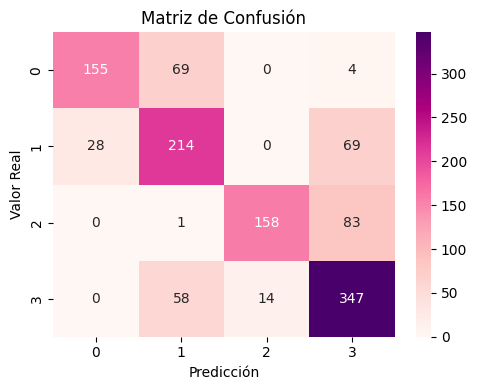

In [7]:
X_train[cat_cols] = X_train[cat_cols].fillna('missing')
X_test[cat_cols] = X_test[cat_cols].fillna('missing')

model_cat = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=False
)
model_cat.fit(X_train, y_train, cat_features = cat_cols)

y_pred = model_cat.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))  # recall 0.7283
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END border_count=32, depth=4, iterations=300, l2_leaf_reg=5, learning_rate=0.01; total time= 1.2min
[CV] END border_count=32, depth=4, iterations=300, l2_leaf_reg=5, learning_rate=0.01; total time= 1.2min
[CV] END border_count=32, depth=4, iterations=300, l2_leaf_reg=5, learning_rate=0.01; total time= 1.2min
[CV] END border_count=32, depth=4, iterations=800, l2_leaf_reg=5, learning_rate=0.01; total time= 3.2min
[CV] END border_count=32, depth=4, iterations=800, l2_leaf_reg=5, learning_rate=0.01; total time= 3.2min
[CV] END border_count=32, depth=4, iterations=800, l2_leaf_reg=5, learning_rate=0.01; total time= 3.3min
[CV] END border_count=64, depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.1; total time= 5.0min
[CV] END border_count=128, depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.05; total time= 5.0min
[CV] END border_count=64, depth=8, iterations=500, l2_leaf_reg=5, learning_rate=0.1; total time= 5.

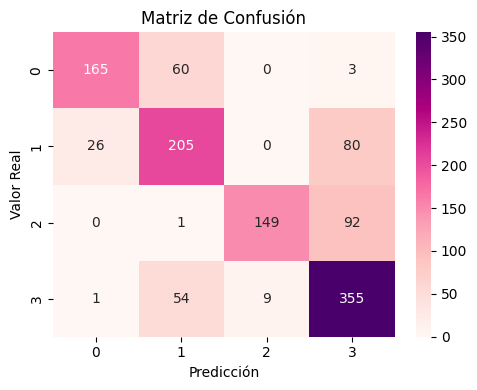

In [8]:
model_cat_base = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=False
)

param_grid = {
    'iterations': [300, 500, 800],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128]
}


grid = RandomizedSearchCV(
    model_cat_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring = 'recall_weighted',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento con categóricas y pesos
grid.fit(
    X_train, y_train,
    cat_features=cat_cols
)

# Evaluación final
best_model = grid.best_estimator_ #{'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 800, 'depth': 6, 'border_count': 64}
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))  # recall 0.7283
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

Accuracy: 0.7283333333333334
Recall: 0.7283333333333334
Precision: 0.7533650068913702
F1-score: 0.7291552262055654

Classification Report:
              precision    recall  f1-score   support

    Critical       0.86      0.72      0.79       228
        High       0.64      0.66      0.65       311
         Low       0.94      0.62      0.74       242
      Medium       0.67      0.85      0.75       419

    accuracy                           0.73      1200
   macro avg       0.78      0.71      0.73      1200
weighted avg       0.75      0.73      0.73      1200



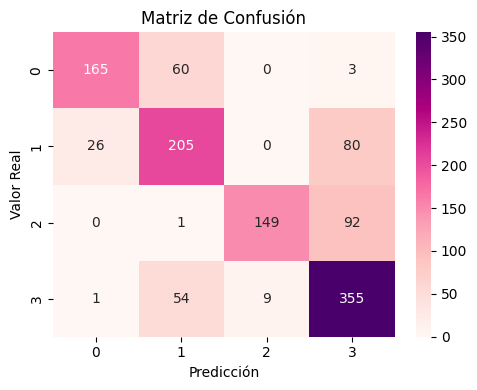

In [9]:
model_cat_best = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    random_seed=42,
    verbose=False,
    learning_rate = 0.05,
    l2_leaf_reg = 1,
    iterations=800,
    depth = 6,
    border_count = 64
)

model_cat_best.fit(X_train, y_train, cat_features = cat_cols)

y_pred = model_cat_best.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))  # recall 0.7283
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdPu')
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()